本节结束后您将能够回答的问题
- 如何让Python代码作为低级代码运行？
- JIT编译器和AOT编译器有什么区别？
- 哪些任务编译后的Python代码可以比原生Python执行得更快？
- 为什么类型注释会加速编译的Python代码？
- 如何使用C或Fortran为Python编写模块？
- 如何在Python中使用C或Fortran中的库？

让代码运行得更快的最简单的方法就是让它做更少的工作。假设您已经选择了好的算法，并且减少了正在处理的数据量，那么执行较少指令的最简单方法就是将代码编译成机器代码。

Python为此提供了许多选项，包括Cython之类的纯C编译方法；基于LLVM的Numba编译；以及替换虚拟机PyPy，其中包括一个内置的实时（JIT）编译器。在决定走哪条路线时，您需要平衡代码适应性和团队速度的需求。

这些工具中的每一个都为您的工具链添加了一个新的依赖项，Cython要求您使用一种新的语言类型（Python和C的混合）进行编写，这意味着您需要一种新的技能。Cython的新语言可能会影响团队的速度，因为不懂C的团队成员可能很难支持这段代码；不过，在实践中，这可能是一个小问题，因为您将只在代码中精心选择的小区域中使用Cython。

值得注意的是，对代码执行CPU和内存评测可能会让您开始考虑可能应用的更高级算法优化。这些算法更改（例如，避免计算的附加逻辑或避免重新计算的缓存）可以帮助您避免在代码中执行不必要的工作，Python的表达能力可以帮助您发现这些算法机会。Radim Řehůřek 在“Making Deep Learning Fly with RadimRehurek.com（2014）（ https://radimrehurek.com/ ）”中讨论了Python实现如何击败纯C实现。

在本节中，我们将回顾以下内容：
- Cython，最常用的编译到C的工具，包括numpy和普通Python代码（需要一些C知识）
- Numba，一种新的专门用于numpy代码的编译器
- PyPy，一个用于非numpy代码的稳定的即时编译器，它是普通Python可执行文件的替代品

在本节的后面，我们将研究外部函数接口，它允许将C代码编译成Python的扩展模块。Python的原生API与ctypes或cffi（来自PyPy的作者）以及f2py Fortran到Python的转换器一起使用。

# 什么样的速度增益是可能的？

如果您的问题屈服于编译方法，则一个数量级或更多的增益是非常可能的。在这里，我们将研究在单个内核上实现1到2个数量级加速的各种方法，以及通过OpenMP使用多个内核。

编译后运行速度更快的Python代码是数学代码，它有许多循环多次重复相同的操作。在这些循环中，您可能正在创建许多临时对象。

调用外部库（如正则表达式、字符串操作和对数据库的调用）的代码在编译后不太可能显示任何加速。I/O绑定的程序也不太可能显示显著的加速。

类似地，如果您的Python代码侧重于调用向量化的numpy例程，那么它在编译之后可能不会运行得更快——只有在编译的代码主要是Python时（可能是在主要是循环时），它才会运行得更快。我们在前面课程中讨论了numpy的运作; 编译并没有真正的帮助，因为中间对象不多。

总的来说，编译后的代码不太可能比手工编写的C例程运行得更快，但也不太可能运行得慢得多。从Python生成的C代码很可能运行得和手写的C例程一样快，除非C代码编写者特别了解如何将C代码调整到目标机器的体系结构。

对于以数学为中心的代码，手工编写的Fortran例程有可能胜过等价的C例程，但同样，这可能需要专家级的知识。总的来说，编译后的结果（可能使用Cython）将与大多数程序员所需要的用C手工编码的结果一样接近。

当你分析和研究你的算法时，记住。通过分析来理解代码的少量工作将使您能够在算法级别做出更明智的选择。在这之后，一些专注于编译器的工作会给你带来额外的加速。也许可以继续调整你的算法，但不要惊讶地发现，你的工作量越来越大，改进也越来越小。知道什么时候额外的努力是无用的。

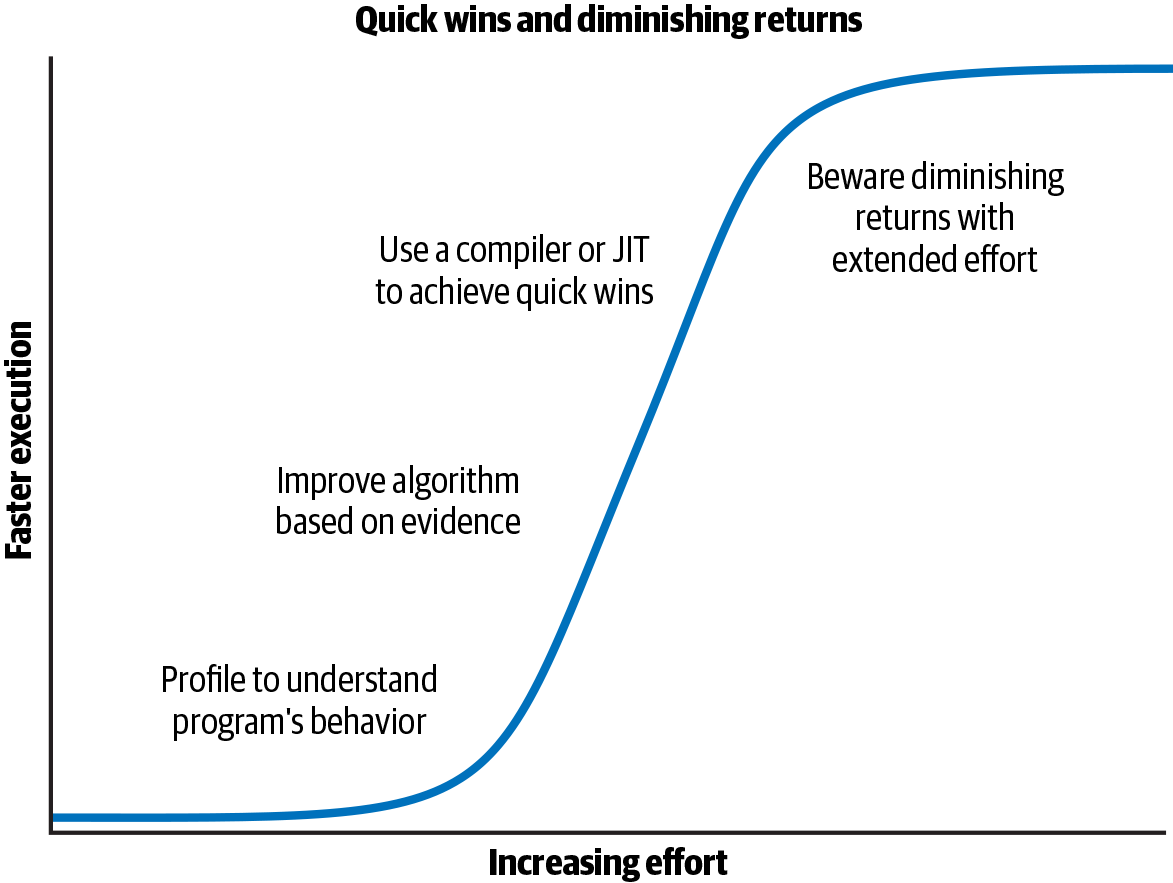

一些评测和编译的工作带来了很多回报，但是持续的工作往往会付出越来越少的代价

如果您处理的是Python代码和在Python安装随附的标准库中包含许多有用的功能库，而不使用numpy，那么Cython和PyPy是您的主要选择。如果你和numpy一起工作，Cython和Numba是正确的选择。这些工具都支持python3.6+。

下面的一些例子需要对C编译器和C代码有一点了解。如果你缺乏这方面的知识，你应该先学一点C语言，然后再编写一个能正常工作的C程序。

# JIT与AOT编译器

我们将要介绍的工具大致分为两组：用于提前编译的工具，或AOT（Cython），以及用于编译“准时”或JIT（Numba，PyPy）的工具。

通过编译AOT，您可以创建一个专用于您的机器的静态库。如果您下载numpy、scipy或scikit learn，它将在您的计算机上使用Cython编译库的一部分（或者，如果您使用的是Continuum's Anaconda之类的发行版，您将使用预构建的编译库）。通过提前编译，您将拥有一个库，可以立即用于解决您的问题。

通过编译JIT，您不必预先做太多（如果有的话）工作；您可以让编译器介入，以便在使用时编译代码的正确部分。这意味着你有一个“冷启动”的问题，如果你的大部分程序可以编译，而目前没有，当你开始运行你的代码，它会运行得非常慢，而它编译。如果每次运行脚本时都会发生这种情况，并且多次运行脚本，那么这一成本可能会非常大。PyPy遇到了这个问题，因此您可能不想将它用于简短但频繁运行的脚本。

当前的状况告诉我们，提前编译可以为我们带来最好的加速，但这通常需要最手动的工作。即时编译提供了一些令人印象深刻的加速，只需很少的手动干预，但它也可能遇到刚才描述的问题。在为您的问题选择合适的技术时，您必须考虑这些权衡。

# 为什么类型信息有助于代码更快地运行？

Python是动态类型化的——变量可以引用任何类型的对象，任何代码行都可以更改所引用对象的类型。这使得虚拟机很难在机器代码级别优化代码的执行方式，因为它不知道未来操作将使用哪种基本数据类型。保持代码的通用性会使它运行得更慢。

在下面的示例中，v是浮点数或表示复数的一对浮点数。这两种情况可能发生在同一个循环中的不同时间点，或在相关的串行代码段中：

In [1]:
v = -1.0
print(type(v), abs(v))

<class 'float'> 1.0


In [2]:
v = 1-1j
print(type(v), abs(v))

<class 'complex'> 1.4142135623730951


abs函数的工作方式因基础数据类型而异。对整数或浮点数使用abs将负值转换为正值。对复数使用abs需要求平方分量和的平方根：

$$abs(c) = \sqrt{c.real^2 + c.imag^2}$$

complex 示例的机器代码涉及更多指令，运行时间更长。在对变量调用abs之前，Python首先要查找变量的类型，然后决定调用哪个版本的函数，当您进行大量重复调用时，这些开销会增加。

在Python中，每个基本对象（如整数）都将被包装在更高级别的Python对象中（如整数的int）。更高级别的对象有额外的函数，`__hash__` 协助储存和`__str__` 用于打印。

在CPU受限的代码段中，变量的类型通常不会改变。这为静态编译和更快的代码执行提供了机会。

如果我们只需要大量的中间数学运算，我们就不需要更高层次的函数，也可能不需要用于参考计数的机器。我们可以降低到机器代码级别，使用机器代码和字节快速地进行计算，而不是操纵更高级别的Python对象，这会带来更大的开销。为此，我们提前确定对象的类型，以便生成正确的C代码。

# 使用C编译器

在下面的示例中，我们将使用 GNU C 编译器工具集中的gcc和g++。如果正确配置环境，则可以使用其他编译器（如Intel的icc或Microsoft的cl）。Cython使用gcc。

gcc对于大多数平台是一个非常好的选择；这是很好的支持和相当先进的。使用经过优化的编译器通常可以获得更高的性能（例如，英特尔的icc可能在英特尔设备上生成比gcc更快的代码），但代价是您必须获得更多的领域知识，并学习如何优化替代编译器上的标志。

C和C++经常被用于静态编译，而不是像FORTRAN这样的其他语言，因为它们的普遍性和支持库的广泛范围。编译器和转换器（如Cython）可以研究带注释的代码，以确定是否可以应用静态优化步骤（如内联函数和展开循环）。

对中间抽象语法树的积极分析（由Numba和PyPy执行）提供了结合Python表达方式的知识的机会，以告知底层编译器如何最好地利用已经看到的模式。

# 回顾Julia集的例子

前面课程我们分析了Julia集生成器。此代码使用整数和复数生成输出图像。图像的计算受CPU限制。

代码中的主要开销是计算输出列表的内部循环的CPU限制特性。此列表可以绘制为方形像素数组，其中每个值表示生成该像素的成本。

代码如下:

In [3]:
"""Julia set generator without optional PIL-based image drawing"""
import time

# area of complex space to investigate
x1, x2, y1, y2 = -1.8, 1.8, -1.8, 1.8
c_real, c_imag = -0.62772, -.42193


def calculate_z_serial_purepython(maxiter, zs, cs):
    """Calculate output list using Julia update rule"""
    output = [0] * len(zs)
    for i in range(len(zs)):
        n = 0
        z = zs[i]
        c = cs[i]
        while n < maxiter and abs(z) < 2:
            z = z * z + c
            n += 1
        output[i] = n
    return output


def calc_pure_python(draw_output, desired_width, max_iterations):
    """Create a list of complex co-ordinates (zs) and complex parameters (cs), build Julia set and display"""
    x_step = (x2 - x1) / desired_width
    y_step = (y1 - y2) / desired_width
    x = []
    y = []
    ycoord = y2
    while ycoord > y1:
        y.append(ycoord)
        ycoord += y_step
    xcoord = x1
    while xcoord < x2:
        x.append(xcoord)
        xcoord += x_step
    # build a list of co-ordinates and the initial condition for each cell.
    # Note that our initial condition is a constant and could easily be removed,
    # we use it to simulate a real-world scenario with several inputs to our function
    zs = []
    cs = []
    for ycoord in y:
        for xcoord in x:
            zs.append(complex(xcoord, ycoord))
            cs.append(complex(c_real, c_imag))

    print("Length of x:", len(x))
    print("Total elements:", len(zs))
    start_time = time.time()
    output = calculate_z_serial_purepython(max_iterations, zs, cs)
    end_time = time.time()
    secs = end_time - start_time
    print(calculate_z_serial_purepython.__name__ + " took", secs, "seconds")

    assert sum(output) == 33219980  # this sum is expected for 1000^2 grid with 300 iterations


if __name__ == "__main__":
    # Calculate the Julia set using a pure Python solution with
    # reasonable defaults for a laptop
    # set draw_output to True to use PIL to draw an image
    calc_pure_python(draw_output=False, desired_width=1000, max_iterations=300)

Length of x: 1000
Total elements: 1000000
calculate_z_serial_purepython took 12.08103895187378 seconds


最初的计算是1000× 使用在cpython3.7上运行的纯Python实现，maxiter=300的1000网格大约需要12秒。

# Cython

Cython是一个编译器，它将带类型注释的Python转换为已编译的扩展模块。类型注释类似于C。可以使用import将此扩展作为常规Python模块导入。入门很简单，但每增加一个复杂度和优化级别，就必须爬升一条学习曲线。这是将计算绑定函数转换为更快代码的首选工具，因为它的广泛使用、成熟度和OpenMP支持。

使用OpenMP标准，可以将并行问题转换为在一台机器上的多个cpu上运行的多处理感知模块。线程对Python代码是隐藏的；它们通过生成的C代码进行操作。
Cython（2007年发布）是Pyrex的一个分支（2002年发布），它扩展了Pyrex最初目标之外的功能。使用Cython的库包括SciPy、sciket-learn、lxml和ZeroMQ。

Cython可以通过setup.py脚本来编译模块。它也可以通过“magic”命令在IPython中交互使用。通常，类型由开发人员进行注释，尽管可以进行一些自动注释。

## 使用Cython编译纯Python版本

开始编写编译扩展模块的简单方法包括三个文件。以我们的Julia集为例，它们如下所示：
- 调用Python代码（前面的Julia代码的大部分）
- 要在新的.pyx文件中编译的函数
- 一个setup.py，包含调用Cython以生成扩展模块的指令

使用这种方法，可以调用setup.py脚本来使用Cython将.pyx文件编译成已编译的模块。在类Unix系统上，编译的模块可能是.so文件；在Windows上，它应该是一个.pyd（类似于Python库的DLL）。

对于Julia示例，我们将使用以下内容：
- julia1.py构建输入列表并调用计算函数
- pyx，它包含我们可以注释的CPU绑定函数
- setup.py，其中包含生成指令

运行setup.py的结果是可以导入的模块。在示例中的julia1.py脚本中 7-2，我们只需要做一些微小的更改就可以导入新模块并调用我们的函数。

我们将从没有类型注释的纯Python版本开始:

cythonfn.pyx（从.py重命名）中用于Cython的setup.py的未修改纯Python代码

setup.py，它将cythonfn.pyx转换为C代码以供Cython编译.下面例中显示的setup.py脚本；它定义了如何将cythonfn.pyx转换为calculate.so。

当我们运行示例中的setup.py脚本时使用参数build_ext，Cython将查找cythonfn.pyx并构建cythonfn[…]。这里将语言级别硬编码为3，以强制支持python3.x。

运行setup.py构建新的已编译模块：

In [6]:
%cd ./julia/cython/cpython

D:\Jupyter\课程教案\03《并行计算与GPU编程》\第02章 Python高性能编程\07_编译到C\julia\cython\cpython


In [18]:
!python setup.py build_ext --inplace

Compiling cythonfn.pyx because it changed.
[1/1] Cythonizing cythonfn.pyx
running build_ext
building 'cythonfn' extension
creating build
creating build\temp.win-amd64-3.7
creating build\temp.win-amd64-3.7\Release
D:\Program Files (x86)\Microsoft Visual Studio 14.0\VC\BIN\x86_amd64\cl.exe /c /nologo /Ox /W3 /GL /DNDEBUG /MD -ID:\ProgramData\Miniconda3\include -ID:\ProgramData\Miniconda3\include "-ID:\Program Files (x86)\Microsoft Visual Studio 14.0\VC\INCLUDE" "-ID:\Program Files (x86)\Microsoft Visual Studio 14.0\VC\ATLMFC\INCLUDE" "-IC:\Program Files (x86)\Windows Kits\10\include\10.0.10150.0\ucrt" "-IC:\Program Files (x86)\Windows Kits\NETFXSDK\4.6\include\um" "-IC:\Program Files (x86)\Windows Kits\8.1\include\shared" "-IC:\Program Files (x86)\Windows Kits\8.1\include\um" "-IC:\Program Files (x86)\Windows Kits\8.1\include\winrt" /Tccythonfn.c /Fobuild\temp.win-amd64-3.7\Release\cythonfn.obj
cythonfn.c
D:\Program Files (x86)\Microsoft Visual Studio 14.0\VC\BIN\x86_amd64\link.exe /nolo

--inplace 参数告诉Cython将编译后的模块构建到当前目录中，而不是单独的构建目录中。在构建完成之后，我们将得到中间的cythonfn.c，它很难阅读，还有cythonfn[…]。

现在，当julia1.py代码运行时，编译的模块被导入，Julia集在本人电脑上以7.99秒计算，而不是通常的 12.08 秒。这是一个非常小的努力有益的改进。

In [19]:
!python julia1.py

Length of x: 1000
Total elements: 1000000
Took 7.99 seconds


## pyximport

通过pyximport引入了一个简化的构建系统。如果您的代码有一个简单的设置并且不需要第三方模块，那么您可以完全取消setup.py。

通过导入pyximport，如下例所示并调用install，任何随后导入的.pyx文件都将自动编译。这个.pyx文件可以包含注释，或者在本例中，它可以是未注释的代码。结果运行时间为8.20秒，与以前一样；唯一的区别是我们不必编写setup.py文件。

In [1]:
%cd ./julia/cython/cpython_pyximport

D:\Jupyter\课程教案\03《并行计算与GPU编程》\第02章 Python高性能编程\07_编译到C\julia\cython\cpython_pyximport


使用pyximport替换setup.py：

In [2]:
!python julia1.py

cythonfn.c
cythonfn.obj : warning LNK4197: 多次指定导出“PyInit_cythonfn”；使用第一个规范
  正在创建库 C:\Users\Administrator\.pyxbld\temp.win-amd64-3.7\Release\Users\Administrator\.pyxbld\temp.win-amd64-3.7\Release\pyrex\cythonfn.cp37-win_amd64.lib 和对象 C:\Users\Administrator\.pyxbld\temp.win-amd64-3.7\Release\Users\Administrator\.pyxbld\temp.win-amd64-3.7\Release\pyrex\cythonfn.cp37-win_amd64.exp
正在生成代码
已完成代码的生成
Length of x: 1000
Total elements: 1000000
Took 8.20 seconds


## 用于分析代码块的Cython注释

前面的示例表明，我们可以快速构建编译后的模块。对于紧循环和数学运算，仅此一项通常会导致加速。显然，我们不应该盲目地优化，我们需要知道哪些代码行需要花费大量的时间，这样我们就可以决定将精力集中在哪里。

Cython有一个注释选项，它将输出一个我们可以在浏览器中查看的HTML文件。我们使用 `cython -a cythonfn.pyx` 命令，并生成输出文件 `cythonfn.html`。在浏览器中查看，Cython文档中提供了类似的图像。

In [3]:
!cython -a cythonfn.pyx

d:\programdata\miniconda3\lib\site-packages\Cython\Compiler\Main.py:369: FutureWarning: Cython directive 'language_level' not set, using 2 for now (Py2). This will change in a later release! File: D:\Jupyter\课程教案\03《并行计算与GPU编程》\第02章 Python高性能编程\07_编译到C\julia\cython\cpython_pyximport\cythonfn.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)


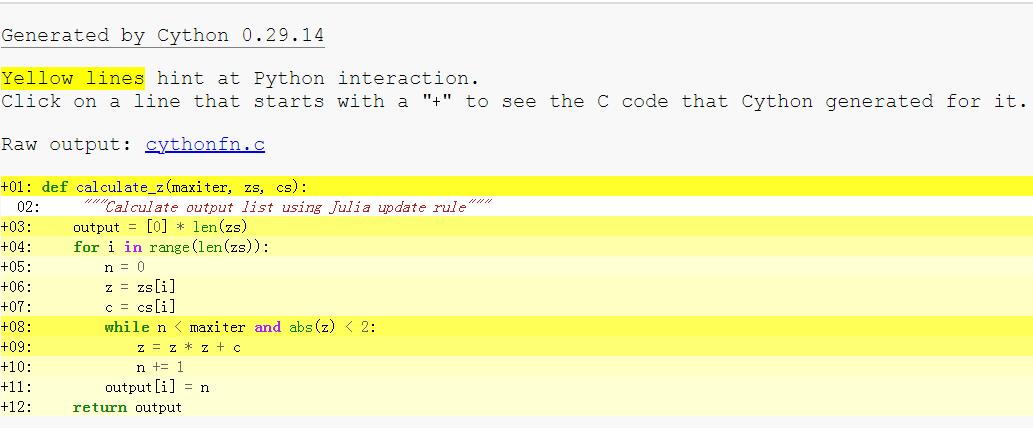

未注函数的彩色Cython输出.

每一行都可以双击展开以显示生成的C代码。更多的黄色表示“更多的调用进入Python虚拟机”，而更多的白色表示“更多的非Python C 代码”，目标是删除尽可能多的黄色行，并以尽可能多的白色结束。

尽管“更多的黄线”意味着对虚拟机的调用更多，但这并不一定会导致代码运行较慢。对虚拟机的每个调用都有成本，但只有在大型循环中进行调用时，这些调用的成本才会显著。相对于内部计算循环的成本而言，大型循环外部的调用（例如，用于在函数开始时创建输出的行）并不昂贵。不要把时间浪费在不会造成减速的线路上。

在我们的示例中，返回到Python虚拟机的调用最多的行（“最黄色”）是第4行和第8行。从我们以前的评测工作中，我们知道第8行可能会被调用超过3000万次，因此这是一个值得关注的候选行。

第9行、第10行和第11行几乎都是黄色的，我们也知道它们在紧密的内部循环中。总的来说，它们将负责这个函数的大部分执行时间，所以我们需要首先关注这些。如果您需要提醒自己在本节中花费了多少时间，请参阅“使用测线探查器逐线测量”。

6号线和7号线没有那么黄，因为它们只被调用了100万次，所以它们对最终速度的影响要小得多，所以我们以后可以关注它们。事实上，由于它们是列表对象，我们实际上无法加快它们的访问速度，除非您将在“Cython and numpy”中看到，用numpy数组替换列表对象，这将带来一点速度优势。

为了更好地理解黄色区域，可以展开每一行。我们可以看到，为了创建输出列表，我们遍历zs的长度，构建新的Python对象，这些对象由Python虚拟机进行引用计数。尽管这些调用很昂贵，但它们不会真正影响此函数的执行时间。

为了缩短函数的执行时间，我们需要开始声明昂贵的内部循环中涉及的对象类型。然后，这些循环可以减少对Python虚拟机的相对昂贵的调用，从而节省我们的时间。

一般来说，花费CPU时间最多的线路是：
- 内部紧密的内环
- 取消引用列表、数组或np.array项
- 进行数学运算

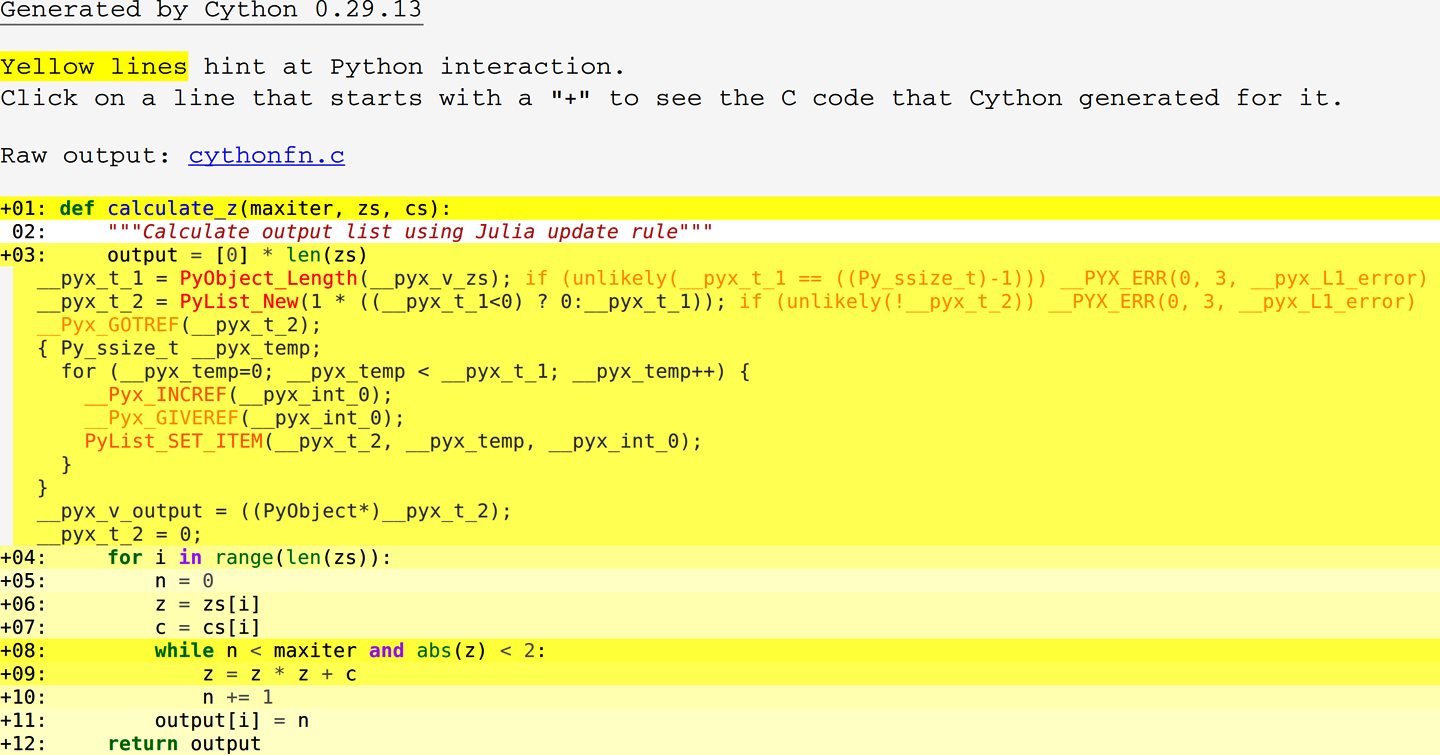

一行Python代码后面的C代码

## 添加一些类型注释

上图显示了我们函数的几乎每一行都在调用回Python虚拟机。当我们使用更高级别的Python对象时，我们所有的数值工作也在调用Python。我们需要将这些对象转换为本地C对象，然后，在完成数字编码之后，我们需要将结果转换回Python对象。

我们将看到如何使用 cdef 语法添加一些基本类型。

我们添加的类型如下：
- `int` 表示有符号整数
- `unsigned int` 表示只能为正的整数
- `double complex` 双精度复数

cdef 关键字允许我们在函数体中声明变量。这些必须在函数的顶部声明，因为这是C语言规范的要求。

添加基本的C类型，通过在C中做更多的工作而通过Python虚拟机做更少的工作，开始使编译后的函数运行得更快。

您可能想知道是否可以将类型注释添加到传入的列表中。我们可以使用list关键字，但这对本例没有实际效果。list对象仍然需要在Python级别进行查询才能提取出它们的内容，这非常缓慢。

将类型赋予一些基本对象的行为反映在图中带注释的输出中. 关键的是，第11行和第12行—我们最常调用的两行—现在已从黄色变为白色，这表明它们不再回调到Python虚拟机。与上一版本相比，我们可以预期会有很大的加速。

我们的第一个类型注释：

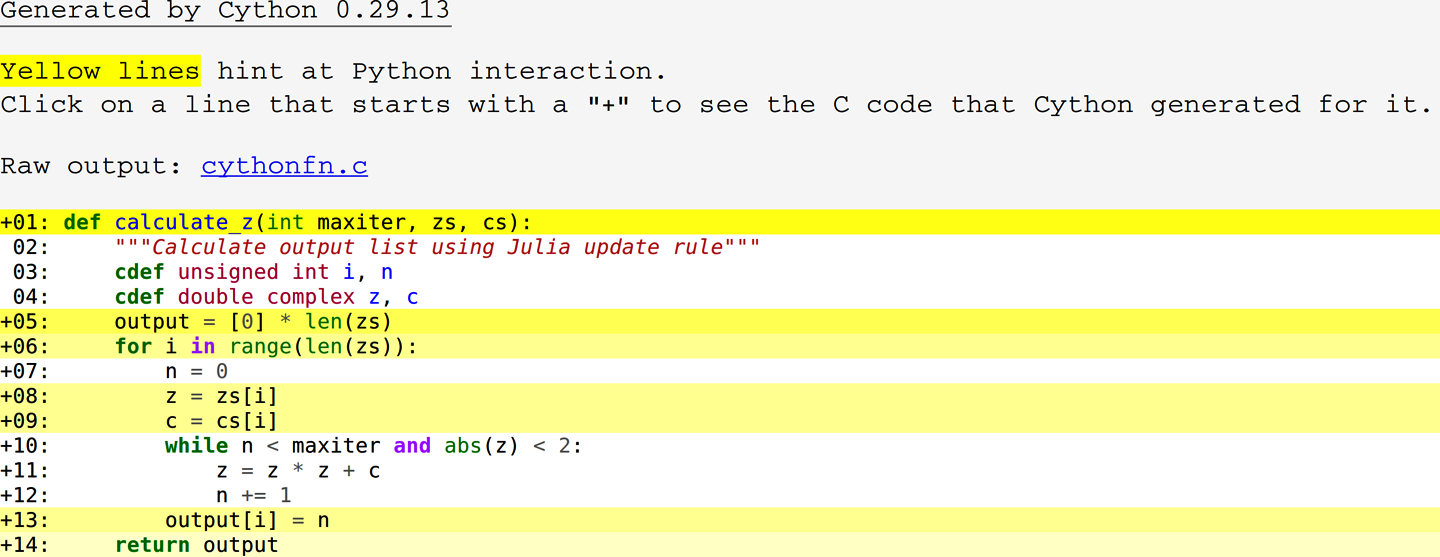

编译后，此版本需要0.49秒才能完成。只需对函数进行一些更改，我们的运行速度是原始Python版本的15倍。

值得注意的是，我们提高速度的原因是，更多频繁执行的操作被下推到C级别，在本例中，是对z和n的更新。这意味着C编译器可以优化底层函数在表示这些变量的字节上的操作方式，而无需调用相对较慢的Python虚拟机。

正如本节前面提到的，复数的绝对值包括实部和虚部平方和的平方根。在我们的测试中，我们想看看结果的平方根是否小于2。与其求平方根，不如求比较的另一边的平方，所以我们把<2变成<4。这避免了将平方根作为abs函数的最后一部分进行计算。

本质上，我们从

$$ \sqrt{c.real^2 + c.imag^2} < \sqrt{4}$$

我们简化了操作

$$c.real^2 + c.imag^2 < 4$$

如果我们在下面的代码中保留sqrt操作，我们仍然可以看到执行速度的提高。优化代码的秘诀之一是使它尽可能少地工作。通过考虑函数的最终目标来删除一个相对昂贵的操作意味着C编译器可以专注于它擅长的东西，而不是试图直觉地理解程序员的最终需求。

编写等价但更专业的代码来解决相同的问题称为强度缩减。为了更快的执行，您需要牺牲较差的灵活性（可能还有较差的可读性）。

这个数学展开引出了一个例子，我们用一条简化的扩展数学线代替了相对昂贵的abs函数。

用Cython扩展abs功能:

通过注释代码，我们看到while在第10行（下图）变得更黄了一点，看起来它可能在做更多的工作而不是更少的工作。目前还不清楚我们将获得多少速度提升，但我们知道这条线的调用次数超过3000万次，因此我们预计会有很好的改进。

这个变化有一个戏剧性的效果，通过减少最内部循环中Python调用的数量，我们大大减少了函数的计算时间。这个新版本只用0.19秒就完成了，惊人的40秒× 比原来的版本快。像以前一样，从你看到的东西中得到一个指导，但是要测试你所有的改变！

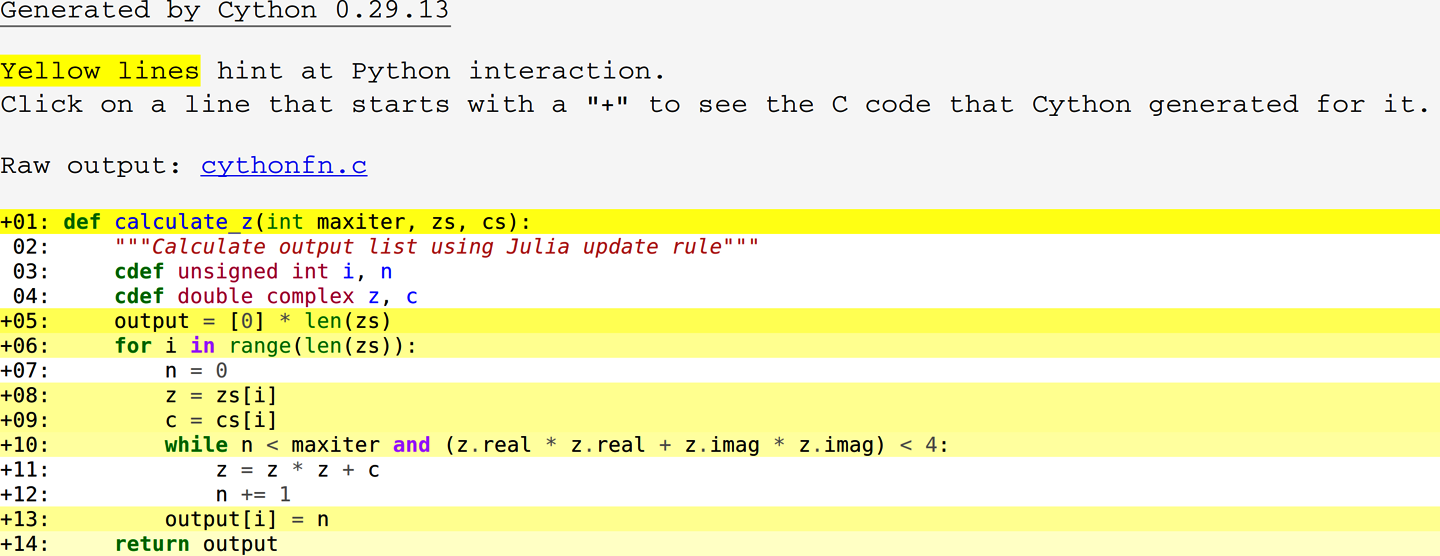

扩展数学以获得最终胜利！

对于这段代码的最后一个可能的改进，我们可以为列表中的每个取消引用禁用边界检查。边界检查的目的是确保程序不会访问C中分配的数组之外的数据很容易意外地访问数组边界之外的内存，这将产生意外的结果（可能是分段错误！）。

默认情况下，Cython保护开发人员避免意外地在列表限制之外寻址。这种保护需要花费一点CPU时间，但是它发生在我们函数的外循环中，所以总的来说不会占用太多时间。禁用边界检查通常是安全的，除非您正在为数组寻址执行自己的计算，在这种情况下，您必须小心地保持在列表的边界内。

Cython有一组可以用各种方式表示的标志。最简单的方法是将它们作为单行注释添加到.pyx文件的开头。也可以使用decorator或编译时标志来更改这些设置。为了禁用边界检查，我们在.pyx文件开头的注释中添加了一个Cython指令：

如前所述，禁用边界检查只会节省一点点时间，因为它发生在外循环中，而不是在更昂贵的内循环中。在这个例子中，这并不能节省我们更多的时间。

## Cython和numpy

list 对象每次取消引用都有一个开销，因为它们引用的对象可以出现在内存中的任何地方。相反，数组对象将基元类型存储在连续的RAM块中，这样可以实现更快的寻址。

Python有array模块，它为基本原语（包括整数、浮点数、字符和Unicode字符串）提供1D存储。NumPy的NumPy.array模块允许多维存储和更广泛的基本类型，包括复数。

当以可预测的方式迭代数组对象时，可以指示编译器避免要求Python计算适当的地址，而是通过直接转到其内存地址来移动到序列中的下一个基本项。由于数据是在一个连续的块中排列的，因此使用偏移量来计算C中下一个项的地址是很简单的，而不是让CPython计算相同的结果，这将涉及到对虚拟机的缓慢回调。

您应该注意，如果您运行下面的numpy版本而没有任何Cython注释（也就是说，如果您只是作为一个普通Python脚本运行它），那么运行时间将远远超过普通Python列表版本（大约需要8秒）。减速是因为取消对numpy列表中单个元素的引用的开销，它从来没有被设计成这样使用，即使对于初学者来说，这可能是处理操作的直观方式。通过编译代码，我们消除了这种开销。

Cython有两种特殊的语法形式。Cython的旧版本对numpy数组有一种特殊的访问类型，但最近通过memoryview引入了通用缓冲区接口协议这允许对实现缓冲区接口的任何对象（包括numpy数组和Python数组）进行相同的低级访问。

buffer接口的另一个好处是，内存块可以很容易地与其他C库共享，而无需将它们从Python对象转换为另一种形式。

下面示例中的代码块看起来有点像最初的实现，只是我们添加了 `memoryview` 注释。函数的第二个参数是 `double complex[：] zs`，这意味着我们有一个使用 `[]` 指定的缓冲协议的双精度复杂对象，它包含一个由单个冒号指定的一维数据块：

Julia计算函数的注释numpy版本:

除了使用buffer注释语法指定输入参数外，我们还注释输出变量，通过empty为其分配一个1dnumpy数组。对empty的调用将分配一个内存块，但不会用合理的值初始化内存，因此它可能包含任何内容。我们将在内部循环中覆盖此数组的内容，因此不需要使用默认值重新分配它。这比使用默认值分配和设置数组的内容要快一些。

我们还通过使用更快、更明确的数学版本扩展了对abs的调用。此版本的运行时间为0.18秒，比示例中纯Python Julia示例的原始Cythonized版本稍微快一点 7-8. 纯Python版本每次取消对Python复杂对象的引用都会有开销，但是这些取消引用发生在外循环中，因此不会占用太多的执行时间。在外循环之后，我们生成这些变量的本机版本，它们以“C速度”运行。这个numpy示例和前一个纯Python示例的内循环都对相同的数据执行相同的工作，因此时间差由外循环取消引用和创建输出数组来计算。

作为参考，如果我们使用前面的代码，但不展开abs数学，那么Cythonized结果需要0.49秒。这个结果使它与早期等价的纯Python版本的运行时完全相同。

## OpenMP并行化解决方案

作为这个版本代码演化的最后一步，让我们看看OpenMP C++扩展的使用来并行化我们尴尬的并行问题。如果您的问题符合此模式，您可以快速利用计算机中的多个核心。

开放式多进程（OpenMP）是一个定义良好的跨平台API，支持C、C++和FORTRAN的并行执行和内存共享。它内置于大多数现代C编译器中，如果C代码编写得当，并行化就发生在编译器级别，因此开发人员通过Cython所做的努力相对较少。

使用Cython，可以通过使用prange（parallel range）操作符并将-fopenmp编译器指令添加到setup.py来添加OpenMP。prange循环中的工作可以并行执行，因为我们禁用了（GIL）。GIL保护对Python对象的访问，防止多个线程或进程同时访问同一内存，这可能导致损坏。通过手动禁用GIL，我们断言不会损坏自己的内存。做这件事时要小心，代码要尽量简单，以避免出现细微的错误。

示例中显示了带有prange支持的代码的修改版本 with nogil：指定禁用GIL的块；在这个块中，我们使用prange启用OpenMP parallel for循环来独立地计算每个i。

添加prange以使用OpenMP实现并行化:

要编译cythonfn.pyx，我们必须修改setup.py脚本，如下示例所示. 我们告诉它在编译期间通知C编译器使用 `-fopenmp` 作为参数来启用 OpenMP 并链接到OpenMP库。

为Cython的setup.py添加OpenMP编译器和链接器标志:

有了Cython的prange，我们可以选择不同的调度方法。使用static时，工作负载平均分布在可用的cpu上。我们的一些计算区域在时间上是昂贵的，而一些是廉价的。如果我们让Cython在CPU上使用static平均调度工作块，那么某些区域的结果将比其他区域更快完成，这些线程将处于空闲状态。

动态和引导调度选项都试图通过在运行时动态地将工作分配到更小的块中来缓解这个问题，这样当工作负载的计算时间可变时，cpu的分布就更均匀了。正确的选择将因工作负载的性质而异。

通过引入OpenMP并使用`schedule=“guided”`，我们将执行时间减少到大约0.05秒，guided时间表将动态分配工作，因此等待新工作的线程将更少。
我们还可以通过使用`#cython:boundscheck=False`来禁用本例的边界检查，但这并不能改善我们的运行时。

# Numba

来自Continuum Analytics的Numba是一个实时编译器，专门处理numpy代码，它在运行时通过LLVM编译器（而不是通过g++或gcc++，正如我们前面的示例所使用的那样）进行编译。它不需要预编译过程，因此当您针对新代码运行它时，它会为您的硬件编译每个带注释的函数。美妙的是，你提供了一个装饰告诉它哪些功能集中，然后你让麻木接管。它的目标是在所有标准numpy代码上运行。

Numba现在是相当稳定的，所以如果您使用numpy数组，并且有迭代许多项的非部门化代码，Numba应该会给您一个快速和非常轻松的胜利。Numba不绑定到外部C库（Cython可以做到），但它可以自动为GPU生成代码（Cython不能做到）。

使用Numba的一个缺点是它使用LLVM的工具链，这有很多依赖项。我们建议您使用Continuum的Anaconda，因为一切都提供了；否则，在一个全新的环境中安装Numba可能是一项非常耗时的任务。

下面例子展示了在我们的核心Julia函数中添加@jit decorator。这就是所需要的；numba已经被导入的事实意味着LLVM机器在执行时启动，在后台编译这个函数。

将@jit decorator应用于函数：

如果删除@jit decorator，这只是运行python3.7的Julia演示的numpy版本，需要21秒。添加@jit decorator会将执行时间降低到0.75秒。这与我们用Cython获得的结果非常接近，但是没有所有的注释工作。

如果我们在同一个Python会话中第二次运行同一个函数，它在0.47秒时运行得更快如果参数类型相同，则无需在第二次运行时编译目标函数，因此总体执行速度更快。在第二次运行时，Numba结果相当于我们之前获得的Cython的numpy结果（因此它的速度和Cython一样快，只需很少的工作！）。PyPy也有同样的预热要求。

如果您想阅读Numba提供的另一个视图，请参阅“Numba”，其中核心开发人员Valentin Haenel谈到了@jit decorator，查看了原始的Python源代码，并进一步介绍了并行选项和类型化列表以及用于纯Python编译互操作性的类型化Dict。

就像Cython一样，我们可以通过prange添加OpenMP并行化支持。下面扩展了decorator，使其不需要任何东西和平行线。nopython说明符意味着如果Numba不能编译所有代码，它将失败。没有这一点，Numba可以安静地退回到一个较慢的Python模式；您的代码将正确运行，但不会看到任何加速。添加parallel可以支持prange。此版本将常规运行时从0.47秒降至0.06秒。目前Numba缺乏对OpenMP调度选项的支持（对于Cython，guided scheduler对于这个问题的运行速度稍微快一点），但是我们希望在未来的版本中会增加支持。

使用prange添加并行化：

调试推断类型：

下例显示调用 `inspect_types()` 的连续输出，其中每行编译代码都显示类型信息。如果您发现无法让 `nopython=True` 工作，那么这个输出是非常宝贵的；在这里，您将能够发现Numba无法识别您的代码的地方。

从Numba那里看中间表征:

Numba是一个强大的JIT编译器，现在已经成熟了。第一次尝试时不要期望有魔力，您可能需要反省生成的代码，以找出如何使代码在nopython模式下编译。一旦你解决了这个问题，你可能会看到好的结果。最好的方法是将当前代码分解成小的（<10行）离散函数，并一次处理这些函数。不要试图把一个大的函数扔进Numba；如果只需要单独查看小的、离散的块，则可以更快地调试流程。

## Numba将为Pandas编写NumPy

在“Pandas”中，我们研究了使用普通最小二乘法解决Pandas数据帧中100000行数据的斜率计算任务。我们可以通过使用Numba使这种方法更快一个数量级。
我们可以使用前面使用的ols_lstsq_raw函数，并用numba.jit修饰，如下示例所示，可以生成一个编译变量。注意 `nopython=True` 参数，如果我们传入一个它不理解的数据类型，它将强制Numba引发一个异常，否则它将静默地返回到纯Python模式。我们不希望它在错误的数据类型上正确运行，但是如果我们传入一个系列，它会在错误的数据类型上缓慢运行；在这里，我们想知道我们传递了错误的数据。在这个版本中，Numba只能编译NumPy数据类型，而不能编译像Series这样的类型。

用numpy求解数据帧上的普通最小二乘法:

当我们第一次调用这个函数时，我们在编译函数时得到了预期的短延迟；处理100000行需要2.3秒，包括编译时间。后续处理100000行的调用非常快，每100000行需要5.3秒，而使用Numba后需要0.58秒。快10倍了！

# PyPy

PyPy是Python语言的另一种实现，它包括一个跟踪即时编译器；它与python3.5+兼容。通常，它落后于Python的最新版本；python3.7是标准的，PyPy最多支持python3.6。

PyPy是CPython的直接替代品，提供所有内置模块。该项目包含RPython翻译工具链，用于构建PyPy（也可以用于构建其他解释器）。PyPy中的JIT编译器非常有效，您只需很少或根本不做任何工作就可以看到良好的加速效果。有关PyPy部署的成功案例，请参阅“PyPy for Successful Web and Data Processing Systems（2014）”。

PyPy运行我们的纯Python Julia演示，没有任何修改。使用CPython需要8秒，使用PyPy需要0.9秒。这意味着PyPy得到的结果非常接近示例中的Cython示例 ，不费吹灰之力，真让人印象深刻！正如我们在讨论Numba时所观察到的，如果在同一个会话中再次运行计算，那么第二次和随后的运行要比第一次运行快，因为它们已经编译好了。

通过扩展数学并删除对abs的调用，PyPy运行时将下降到0.2秒。这相当于使用纯Python和numpy的Cython版本，没有任何工作！请注意，只有在不将numpy与PyPy一起使用时，此结果才是正确的。

PyPy支持所有内置模块这一事实很有趣，这意味着多处理的工作方式与CPython相同。如果你有一个问题，运行包括模块，可以并行运行多处理，你可以期待所有的速度增益，你可能希望得到将是可用的。

PyPy的速度是随着时间的推移而变化的。下图中较旧的图表（来自speed.pypy.org）将让您了解pypy的成熟度。这些速度测试反映了广泛的用例，而不仅仅是数学运算。很明显，PyPy提供了比CPython更快的体验。

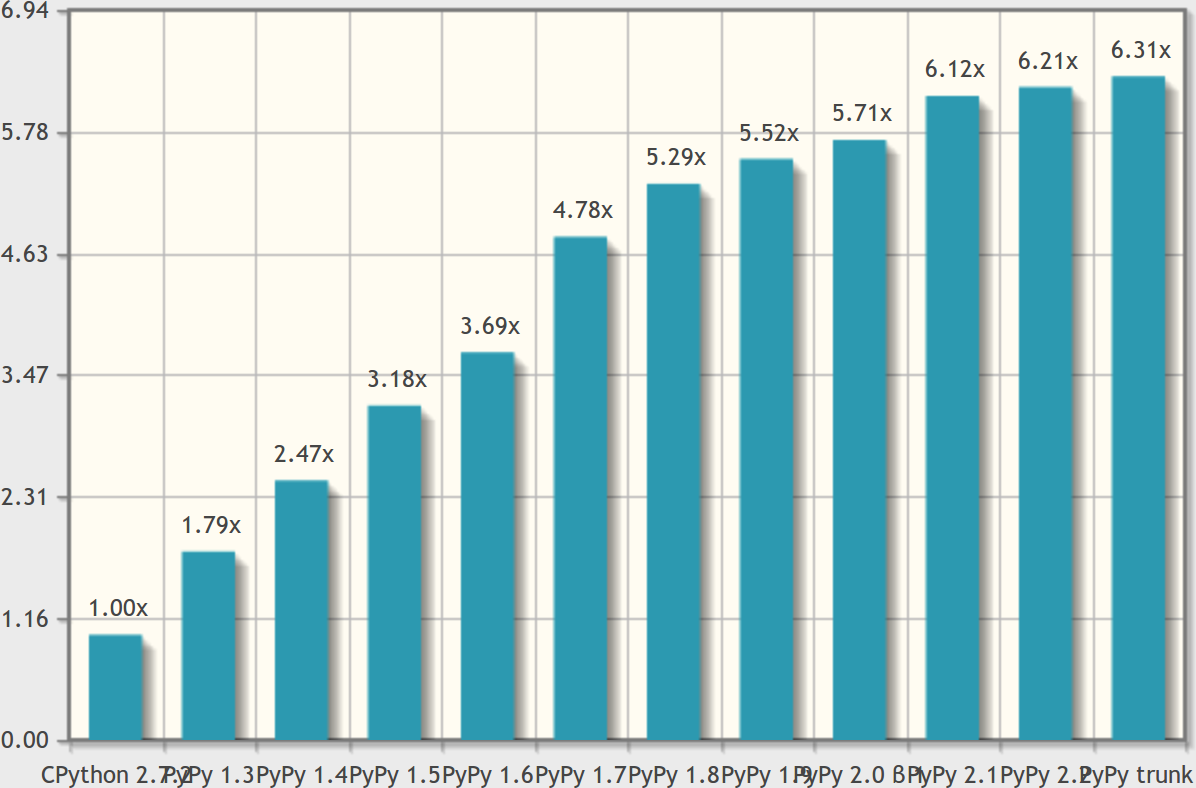

PyPy的每个新版本都提供了速度改进。

## 垃圾收集差异

PyPy使用了与CPython不同的垃圾收集器类型，这可能会对代码造成一些不明显的行为更改。而CPython使用引用计数，PyPy使用一种改进的标记和扫描方法，这种方法可能会在很长时间后清除未使用的对象。两者都是Python规范的正确实现；您只需要知道在交换时可能需要修改代码。

在CPython中看到的一些编码方法依赖于引用计数器的行为，特别是文件的刷新，如果您在没有显式关闭文件的情况下打开和写入文件。使用PyPy时，将运行相同的代码，但对文件的更新可能会在垃圾收集器下次运行时刷新到磁盘。在PyPy和Python中都可以使用的另一种形式是使用上下文管理器来打开和自动关闭文件。PyPy网站上的PyPy和CPython页面的区别列出了细节。

## 运行PyPy并安装模块

如果您从未运行过替代的Python解释器，那么您可能会从一个简短的示例中受益。假设您已经下载并提取了PyPy，那么现在就有了一个包含bin目录的文件夹结构。如示例所示开始PyPy运行它。

1. 下载 pypy3.7-v7.3.4-win64

2. 安装配置环境变量

直接解压：D:\ProgramData\pypy3.7-v7.3.4-win64

配置环境变量：

鼠标右键单击——>属性——>高级系统设置——>环境变量——>系统变量——>path——>编辑——>新建——>

解压后的文件地址（D:\ProgramData\pypy3.7-v7.3.4-win64;D:\ProgramData\pypy3.7-v7.3.4-win64\Scripts）——>确定

检测是否配置成功：

win+R——>输入cmd，则表示成功！！

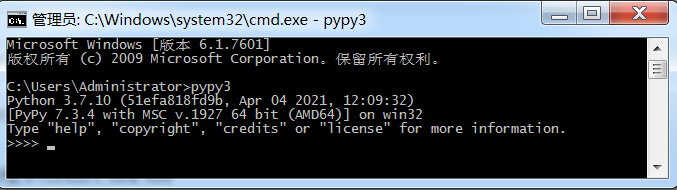

3. 安装配置好之后 安装第三方库

接下来进行安装pypy的pip 和requests:

下载地址：https://bootstrap.pypa.io/get-pip.py

下载好之后，将get-pip.py文件放入解压后的文件夹下，输入cmd进黑窗口输入以下的命令，如下图，并将bin文件夹配置到环境变量：

4. 环境配好了就可以安装第三方库

如此环境就搭建好好了！

5. 安装IPython

注意，PyPy支持像numpy这样的项目，这些项目需要通过CPython扩展兼容层cpyext进行C绑定，但是它的开销为4–6×, 这通常会使numpy太慢。如果您的代码大部分是纯Python，只调用了几个numpy，那么您仍然可以看到显著的总体收益。如果您的代码（如Julia示例）多次调用numpy，那么它的运行速度会明显减慢。这里的Julia基准测试使用numpy数组运行6× 比用CPython运行时慢。

如果您需要其他软件包，那么应该通过cpyext兼容模块安装它们，该模块实际上是PyPy的python.h版本。它处理PyPy和CPython的不同内存管理需求；然而，这种管理会产生4-6%的成本× 每次托管调用，因此numpy的速度优势可能会被此开销抵消。一个名为HPy（以前叫PyHandle）的新项目旨在通过提供一个更高级别的对象句柄来消除这种开销，这个对象句柄不绑定到CPython的实现，可以与Cython等其他项目共享。

如果您想了解PyPy的性能特征，请查看vmprof轻量级采样探查器。它是线程安全的，支持基于web的用户界面。

PyPy的另一个缺点是它可以使用大量的RAM。每个版本在这方面都更好，但实际上它可能比CPython使用更多的RAM。不过，RAM相当便宜，所以用它来换取增强的性能是有道理的。一些用户还报告说，在使用PyPy时，RAM使用率较低。和以往一样，如果这对你很重要的话，用有代表性的数据做一个实验。

# 速度提升总结

<table id="table_compiler_results1" class="pagebreak-before less_space">
<caption><span class="label">Table 7-1. </span>Julia (no <code>numpy</code>) results</caption>
<thead>
<tr>
<th>&nbsp;</th>
<th>Speed</th>
</tr>
</thead>
<tbody>
<tr>
<td><p>CPython</p></td>
<td><p>8.00s</p></td>
</tr>
<tr>
<td><p>Cython</p></td>
<td><p>0.49s</p></td>
</tr>
<tr>
<td><p>Cython on expanded math</p></td>
<td><p>0.19s</p></td>
</tr>
<tr>
<td><p>PyPy</p></td>
<td><p>0.90s</p></td>
</tr>
<tr>
<td><p>PyPy on expanded math</p></td>
<td><p>0.20s</p></td>
</tr>
</tbody>
</table>

带有numpy的Julia解算器支持OpenMP的研究。在下表中，我们看到Cython和Numba都比非numpy版本的扩展数学运行得更快。当我们添加OpenMP时，Cython和Numba都提供了进一步的加速，只需要很少的额外编码。

<table id="table_compiler_results2">
<caption><span class="label">Table 7-2. </span>Julia (with <code>numpy</code> and expanded math) results</caption>
<thead>
<tr>
<th></th>
<th>Speed</th>
</tr>
</thead>
<tbody>
<tr>
<td><p>CPython</p></td>
<td><p>21.00s</p></td>
</tr>
<tr>
<td><p>Cython</p></td>
<td><p>0.18s</p></td>
</tr>
<tr>
<td><p>Cython and OpenMP “guided”</p></td>
<td><p>0.05s</p></td>
</tr>
<tr>
<td><p>Numba (2nd &amp; subsequent runs)</p></td>
<td><p>0.17s</p></td>
</tr>
<tr>
<td><p>Numba and OpenMP</p></td>
<td><p>0.06s</p></td>
</tr>
</tbody>
</table>

对于纯Python代码，PyPy显然是首选。对于numpy代码，Numba是一个很好的首选。

# 每种技术何时使用

如果你正在从事一个数字项目，那么这些技术中的每一项都可能对你有用。下表总结了主要选项。

<table id="table_compiler_summary">
<caption><span class="label">Table 7-3. </span>Compiler options</caption>
<thead>
<tr>
<th></th>
<th>Cython</th>
<th>Numba</th>
<th>PyPy</th>
</tr>
</thead>
<tbody>
<tr>
<td><p>Mature</p></td>
<td><p>Y</p></td>
<td><p>Y</p></td>
<td><p>Y</p></td>
</tr>
<tr>
<td><p>Widespread</p></td>
<td><p>Y</p></td>
<td><p>–</p></td>
<td><p>–</p></td>
</tr>
<tr>
<td><p><code>numpy</code> support</p></td>
<td><p>Y</p></td>
<td><p>Y</p></td>
<td><p>Y</p></td>
</tr>
<tr>
<td><p>Nonbreaking code changes</p></td>
<td><p>–</p></td>
<td><p>Y</p></td>
<td><p>Y</p></td>
</tr>
<tr>
<td><p>Needs C knowledge</p></td>
<td><p>Y</p></td>
<td><p>–</p></td>
<td><p>–</p></td>
</tr>
<tr>
<td><p>Supports OpenMP</p></td>
<td><p>Y</p></td>
<td><p>Y</p></td>
<td><p>–</p></td>
</tr>
</tbody>
</table>

Numba可以快速提升，但它也有一些限制，可能会阻止它在您的代码上很好地工作。这也是一个相对年轻的项目。

Cython可能为最广泛的一系列问题提供了最好的结果，但是它确实需要更多的努力，并且由于混合了Python和C注释。

如果您不使用numpy或其他难以移植的C扩展，PyPy是一个强大的选项。

如果您正在部署一个生产工具，您可能希望坚持使用易于理解的工具Cython应该是您的主要选择，您可能希望查看“Making Deep Learning Fly with RadimRehurek.com（2014）”。PyPy也被用于生产设置（参见“PyPy for Successful Web and Data Processing Systems（2014）”）。

如果您使用的是轻数值要求，请注意Cython的缓冲区接口接受array.array materials这是一种简单的方法，可以将数据块传递给Cython以进行快速数值处理，而不必将numpy添加为项目依赖项。

总的来说，Numba正在成熟，是一个有前途的项目，而Cython是成熟的。PyPy现在被认为是相当成熟的，应该针对长时间运行的流程进行评估。

建议有能力的同学实现了Julia算法的C版本，并且比较它比Cython版本执行快慢。C版本尽管比自动生成的Cython版本要短得多，但运行速度大致相同。编写原始的C版本，比较其速度，并找出如何修复它所花费的时间比最初使用Cython要长。

这里，我们并不是说Cython将生成最好的代码，有能力的C程序员可能会想出如何使他们的代码比Cython生成的版本运行得更快。不过，值得注意的是，手写C将比转换后的Python更快的假设并不安全。你必须始终以证据为基准并做出决定。C编译器非常擅长将代码转换成相当高效的机器代码，Python也非常擅长让您用一种易于理解的语言来表达您的问题，将这两种能力合理地结合起来。

# 其他即将开展的项目

1. PyData编译器页面列出了一组高性能和编译器工具。

2. Pythran是一个面向使用numpy的科学家的AOT编译器。使用很少的注释，它可以将Python数字代码编译成更快的二进制代码，它可以产生与Cython非常相似的加速，但所需的工作量要少得多。在其他功能中，它总是发布GIL，并且可以同时使用SIMD指令和OpenMP。和Numba一样，它不支持类。如果在Numpy中有紧密的、局部绑定的循环，那么Pythran当然值得评估。相关的FluidPython项目旨在使Pythran更易于编写，并提供JIT功能。

3. Transonic试图将Cython、Pythran和Numba以及其他可能的编译器统一到一个接口后面，以便在不重写代码的情况下快速评估多个编译器。

4. ShedSkin是一个面向非科学的纯Python代码的AOT编译器。它不支持numpy，但是如果您的代码是纯Python，ShedSkin会产生与PyPy类似的加速（不使用numpy）。它支持Python2.7和一些Python3.x支持。

5. PyCUDA和PyOpenCL提供了到Python的CUDA和OpenCL绑定，以便直接访问GPU。这两个库都很成熟，都支持python3.4+。

6. Nuitka是一个Python编译器，它的目标是成为普通CPython解释器的替代品，可以选择创建已编译的可执行文件。它支持所有python3.7，尽管在我们的测试中，它没有为我们的普通Python数值测试带来任何明显的速度提升。

有些社区拥有大量的编译选项。虽然它们都有折衷之处，但它们也提供了大量的功能，因此复杂的项目可以充分利用CPU和多核体系结构的全部功能。

# 图形处理单元（GPU）

图形处理单元（GPU）作为一种加速算法繁重的计算负载的方法正变得非常流行。最初设计用于帮助处理三维图形的繁重线性代数要求，GPU特别适合于解决易于并行化的问题。

有趣的是，如果我们只看时钟速度的话，GPU本身比大多数CPU都慢。这似乎有悖常理，但正如我们在“计算单元”中所讨论的，时钟速度只是衡量硬件计算能力的一个指标。GPU擅长大规模并行化任务，因为它们拥有惊人数量的计算核心。CPU通常有12个内核，而现代的GPU有数千个。

这种难以置信的并行性可以将许多数字任务的速度提高到惊人的程度。然而，在这些设备上编程可能相当困难。由于并行性的数量，需要考虑数据的局部性，并且在获得加速方面可以决定成败。有很多工具可以用Python编写本地GPU代码（也称为内核），比如CuPy。然而，现代深度学习算法的需求已经将新的接口推入GPU中，这些接口易于使用且直观。

在易于使用的GPU数学库方面，两个领先者是TensorFlow和PyTorch。我们将重点介绍PyTorch的易用性和速度。

## 动态图形：PyTorch

PyTorch是一个静态计算图张量库，它特别友好，对于熟悉numpy的任何人都有非常直观的API。此外，由于它是一个张量库，因此它具有与numpy相同的功能，还有一个额外的优点，即可以通过静态计算图创建函数，并使用称为autograd的机制计算这些函数的导数。

通过静态计算图，我们的意思是对PyTorch对象执行操作会创建一个程序的动态定义，该程序在执行时会在后台编译为GPU代码（与“JIT vs AOT编译器”中的JIT完全相同）。由于它是动态的，对Python代码的更改会自动反映在GPU代码中，而不需要显式的编译步骤。与TensorFlow等静态图形库相比，这大大有助于调试和交互性。

在静态图中，如TensorFlow，我们首先设置计算，然后编译它。从那时起，我们的计算是一成不变的，我们只能通过重新编译整个东西来改变它。利用PyTorch的动态图，我们可以有条件地改变计算图或者迭代地建立它。这允许我们在代码中进行条件调试，或者让我们在IPython的交互式会话中使用GPU。在处理基于GPU的复杂工作负载时，灵活控制GPU的能力完全改变了游戏规则。

作为一个例子，库的易用性以及它的速度，在下面例子，我们使用PyTorch的GPU移植示例中的numpy代码：

In [2]:
import timeit

from numpy import roll, zeros

GRID_SHAPE = (640, 640)


def laplacian(grid):
    return (
        roll(grid, +1, 0)
        + roll(grid, -1, 0)
        + roll(grid, +1, 1)
        + roll(grid, -1, 1)
        - 4 * grid
    )


def evolve(grid, dt, D=1):
    return grid + dt * D * laplacian(grid)


def run_experiment(num_iterations, grid_shape=GRID_SHAPE):
    grid = zeros(grid_shape)

    block_low = int(grid_shape[0] * 0.4)
    block_high = int(grid_shape[0] * 0.5)
    grid[block_low:block_high, block_low:block_high] = 0.005

    for i in range(num_iterations):
        grid = evolve(grid, 0.1)
    return grid


if __name__ == "__main__":
    n_iter = 100
    N, runtime = timeit.Timer(
        f"run_experiment({n_iter})", globals=globals()
    ).autorange()
    print(f"Runtime with grid {GRID_SHAPE}: {runtime / N:0.4f}s")

Runtime with grid (640, 640): 2.0012s


PyTorch 2D扩散：

In [4]:
import pandas as pd
import torch
from torch import (roll, zeros)  #唯一需要的改变。

grid_shape = (640, 640)

def laplacian(grid):
    return (
        roll(grid, +1, 0)
        + roll(grid, -1, 0)
        + roll(grid, +1, 1)
        + roll(grid, -1, 1)
        - 4 * grid
    )

def evolve(grid, dt, D=1):
    return grid + dt * D * laplacian(grid)

def run_experiment(num_iterations):
    grid = zeros(grid_shape)

    block_low = int(grid_shape[0] * 0.4)
    block_high = int(grid_shape[0] * 0.5)
    grid[block_low:block_high, block_low:block_high] = 0.005

    grid = grid.cuda()  #唯一需要的改变。
    for i in range(num_iterations):
        grid = evolve(grid, 0.1)
    return grid

if __name__ == "__main__":
    n_iter = 100
    N, runtime = timeit.Timer(
        f"run_experiment({n_iter})", globals=globals()
    ).autorange()
    print(f"Runtime with grid {grid_shape}: {runtime / N:0.4f}s")

Runtime with grid (640, 640): 0.0694s


大部分工作都是在修改后的import中完成的，我们将numpy改为torch。事实上，如果我们只想在CPU上运行优化的代码，我们可以到此为止。要使用GPU，我们只需将数据移动到GPU，然后torch就会自动将我们对这些数据所做的所有计算编译成GPU代码。

如下图所示，这个小小的代码改变给了我们一个难以置信的加速 × 512 grid ，我们有5.3 grid × 加速，对于4096× 4096网格我们有一个 102× 加速！有趣的是，GPU代码似乎不像numpy代码那样受网格大小增加的影响。

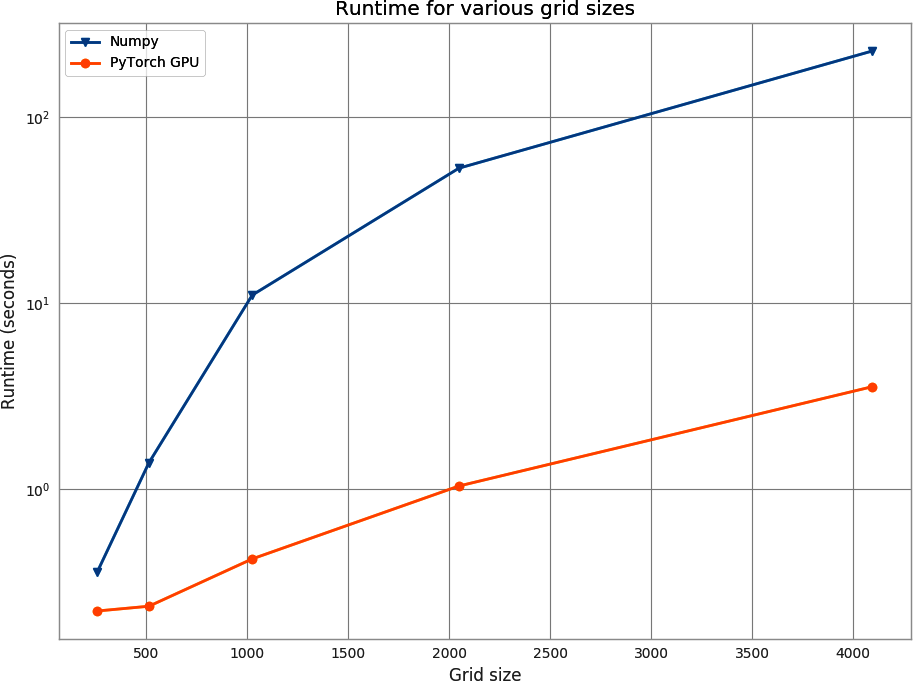

Pytork vs numpy 性能

这种加速是扩散问题可并行化的结果。如前所述，我们使用的GPU有640个独立的计算核心。似乎一旦扩散问题被并行化，这些GPU核心就没有一个得到充分利用。

警告

在对GPU代码的性能进行计时时，设置环境标志 `CUDA_LAUNCH_BLOCKING=1` 非常重要。默认情况下，GPU操作是异步运行的，以允许更多的操作被流水线连接在一起，从而最小化GPU的总利用率并提高并行化。当异步行为被启用时，我们可以保证只有当数据被复制到另一个设备或者发出 `torch.cuda.synchronize()` 命令时，计算才会完成。通过启用前面的环境变量，我们可以确保计算在发出时完成，并且我们确实在测量计算时间。

## 基本GPU配置

一种验证我们正在使用的GPU的方法是通过使用 `nvidia-smi` 命令来检查GPU的资源利用率。我们最感兴趣的两个值是功耗和GPU利用率：

需要在path添加 如下 路径才可以直接在cmd中使用nvidia-smi命令等。

C:\Program Files\NVIDIA Corporation\NVSMI
 

然后在命令行中输入nvidia-smi.exe就可以查看GPU的情况

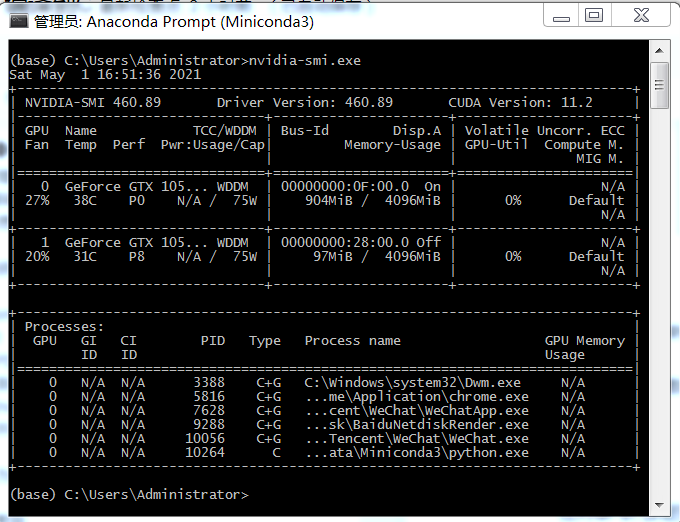

GPU的利用率，它告诉我们运行至少一个内核的时间占最后一秒的百分比。但它并没有告诉我们GPU的计算能力占总计算能力的百分比，而是告诉我们有多少时间没有被闲置。在调试内存传输问题并确保CPU为GPU提供足够的工作时，这是一个非常有用的度量。

另一方面，功耗是判断GPU的计算能力的一个很好的指标。根据经验，GPU的功耗越大，它当前的计算量就越大。如果GPU正在等待来自CPU的数据，或者只使用了可用内核的一半，那么功耗将从最大值降低。

另一个有用的工具是gpustat。这个项目使用比nvidiasmi更友好的界面提供了一个很好的视图来查看NVIDIA的许多统计信息。

为了帮助理解具体是什么导致PyTorch代码减速，该项目提供了一个特殊的分析工具。使用 `python -m torch.utils.bottleneck` 运行代码时，将显示CPU和GPU运行时统计信息，以帮助您确定对代码任何部分的潜在优化。

## GPU的性能考虑

由于GPU是计算机上完全辅助的硬件，与CPU相比，它有自己的体系结构，因此需要记住许多GPU特定的性能考虑。

GPU最大的速度考虑是从系统内存到GPU内存的数据传输时间。当我们使用 tensor.to（设备）时，我们触发的数据传输可能需要一些时间，这取决于GPU总线的速度和传输的数据量。

其他操作也可能触发传输。特别是，tensor.items（）和tensor.tolist（）在为调试目的引入时常常会导致问题。事实上，运行tensor.numpy（）将PyTorch张量转换为numpy数组特别需要一个GPU的显式副本，这可以确保您了解潜在的惩罚。

例如，让我们在扩散代码的解算器循环中添加一个grid.cpu（）调用：

为了确保公平比较，我们还将在控制代码中添加`torch.cuda.synchronize()`，这样我们就可以简单地测试从CPU复制数据的时间。除了通过触发从GPU到系统内存的数据传输来降低代码的速度外，您的代码还将降低速度，因为GPU将暂停在后台继续执行的代码，直到传输完成。

这是2048的代码变化× 2048网格使我们的代码慢了2.54×! 即使我们的GPU有一个616.0gb/s的带宽，这个开销也会很快增加。此外，其他开销与内存拷贝相关。首先，我们正在为代码执行的任何潜在流水线创建一个硬停止。然后，因为我们不再是流水线，我们在GPU上的数据必须全部同步出各个CUDA内核的内存。最后，需要准备好系统内存上的空间，以便从GPU接收新数据。

虽然这看起来像是对我们的代码添加了一个内容，但这种事情总是发生。事实上，当涉及到深度学习时，阻碍PyTorch代码的最大的事情之一就是将训练数据从主机复制到GPU中。通常情况下，训练数据太大，无法放在GPU上，进行这些持续的数据传输是不可避免的惩罚。

当问题从CPU转移到GPU时，有一些方法可以减轻这种不可避免的数据传输带来的开销。首先，可以将内存区域标记为pinned。这可以通过调用`Tensor.pin_memory()` 方法来实现，该方法返回复制到内存“页面锁定”区域的CPU张量的副本。这个页面锁定区域可以更快地复制到GPU，并且可以异步复制，这样就不会干扰GPU正在进行的任何计算。在训练深度学习模型时，数据加载通常是用DataLoader类完成的，DataLoader类有一个`pin_memory` 参数，可以自动为所有训练数据加载数据。

最重要的一步是使用“基本GPU评测”中概述的工具评测代码。当您的代码花费大部分时间进行数据传输时，您将看到低功耗、较小的GPU利用率（如nvidia smi所报告的），以及大部分时间花费在to功能上（如 bottleneck 所报告的）。理想情况下，您将使用GPU所能支持的最大功率，并具有100%的利用率。这是可能的，即使在大量的数据传输是必要的，即使是在训练深入学习模型与大量的图像！

## 何时使用GPU

我们已经看到GPU可以非常快；然而，内存方面的考虑对这个运行时来说可能是非常有害的。这似乎表明，如果您的任务主要需要线性代数和矩阵操作（如乘法、加法和傅立叶变换），那么GPU是一个极好的工具。如果计算可以在GPU上不间断地进行一段时间，然后再复制回系统内存，那么这一点尤其正确。

作为一个需要大量分支的任务的例子，我们可以想象这样的代码：计算的每一步都需要前面的结果。如果我们比较运行下面示例，使用PyTorch与使用NumPy相比，我们看到NumPy始终更快（包括的示例中，更快了98%）。考虑到GPU的体系结构，这是有意义的。虽然GPU一次可以运行比CPU多得多的任务，但是每个任务在GPU上的运行速度都比在CPU上慢。这个示例任务一次只能运行一个计算，因此拥有许多计算核心根本没有帮助；最好是有一个非常快的核心。

高度分支任务：

In [5]:
import torch

def task(A, target):
    """
    Given an int array of length N with values from (0, N] and a target value,
    iterates through the array, using the current value to find the next array
    item to look at, until we have seen a total value of at least `target`.
    Returns how many iterations until the value was reached.
    """
    result = 0
    i = 0
    N = 0
    while result < target:
        r = A[i]
        result += r
        i = A[i]
        N += 1
    return N

if __name__ == "__main__":
    N = 1000

    A_py = (torch.rand(N) * N).type(torch.int).to('cuda:0')
    A_np = A_py.cpu().numpy()

    task(A_py, 500)
    task(A_np, 500)

此外，由于GPU的内存有限，对于需要大量数据、对数据进行许多有条件的操作或更改数据的任务，它不是一个好的工具。大多数用于计算任务的GPU都有大约12GB的内存，这对“大量数据”造成了很大的限制。然而，随着技术的进步，GPU内存的大小也在增加，所以希望这种限制在未来不会那么严重。

评估是否使用GPU的一般方法包括以下步骤：
1. 确保问题的内存使用适合GPU（在“使用内存配置器诊断内存使用情况”中，我们探讨了配置内存使用情况）。
2. 评估算法是否需要大量分支条件而不是向量化操作。根据经验，numpy函数通常向量化得非常好，因此如果您的算法可以用numpy调用编写，那么您的代码可能会向量化得很好！您还可以在运行perf时检查分支结果（如“了解perf”中所述）。
3. 评估需要在GPU和CPU之间移动多少数据。这里要问的一些问题是“在我需要打印/保存结果之前，我能做多少计算？”和“我的代码是否有时必须复制数据才能在一个我知道与GPU不兼容的库中运行？”
4. 确保PyTorch支持您想做的操作！PyTorch实现了numpy API的很大一部分，所以这应该不是问题。在大多数情况下，API甚至是相同的，所以您根本不需要更改代码。但是，在某些情况下，PyTorch不支持操作（例如处理复数），或者API略有不同（例如，生成随机数）。

考虑到这四点将有助于给你信心，GPU的方法将是值得的。关于GPU何时能比CPU工作得更好，没有硬性规定，但这些问题会帮助你获得一些直觉。然而，PyTorch也使得使用GPU的代码转换变得轻松，所以进入的门槛相当低，即使您只是评估GPU的性能。

# 外部函数接口

有时，自动解决方案无法解决问题，您需要自己编写定制的C或Fortran代码。这可能是因为编译方法找不到一些潜在的优化，或者您希望利用Python中不可用的库或语言特性。在所有这些情况下，您都需要使用外部函数接口，它允许您访问用另一种语言编写和编译的代码。

在本节的其余部分中，我们将尝试使用一个外部库来解决2D扩散方程，如下示例所示，可以代表您安装的库或您编写的代码。我们将研究的方法是一种很好的方法，它可以将代码的一小部分转移到另一种语言中，以便进行非常有针对性的基于语言的优化。

求解二维扩散问题的C代码示例：

要使用此代码，我们必须将其编译到一个共享模块中，该模块创建一个.so文件。我们可以使用gcc（或任何其他C编译器）通过以下步骤来完成：

In [6]:
!gcc -O3 -std=gnu11 -c diffusion.c

In [7]:
!gcc -shared -o diffusion.so diffusion.o

我们可以将这个最终的共享库文件放在Python代码可以访问的任何地方，但是标准*nix组织将共享库存储在/usr/lib和/usr/local/lib中。

## ctypes

CPython中最基本的外部函数接口是通过ctypes模块实现的。7这个模块的基本特性可能会在您负责做任何事情的时候起到很大的抑制作用，并且可能需要相当长的时间才能确保您将所有事情都安排好。这个额外的复杂性在我们的ctypes扩散代码中很明显，如示例所示如下：

我们要做的第一件事就是“import”我们的共享库。这是通过 ctypes.CDLL 调用完成的。在这行中，我们可以指定Python可以访问的任何共享库（例如，ctypes-opencv 模块加载libcv.so库）。由此，我们得到一个包含共享库包含的所有成员的 `_diffusion` 对象。在本例中，diffusion.so只包含一个函数evolve，它现在作为\u diffusion对象的属性提供给我们。如果diffusion.so有许多函数和属性，那么我们可以通过u diffusion对象访问它们。

然而，即使 `_diffusion` 对象中有可用的evolve函数，Python也不知道如何使用它。C是静态类型的，函数有一个非常特殊的签名。为了正确地使用evolve函数，我们必须显式地设置输入参数类型和返回类型。在与Python接口一起开发库时，或者在处理快速变化的库时，这可能会变得非常乏味。此外，由于ctypes无法检查您是否为其提供了正确的类型，因此如果您犯了错误，代码可能会自动失败或segfault！

此外，除了设置函数对象的参数和返回类型外，我们还需要转换任何我们想与之一起使用的数据（这称为casting）。我们发送给函数的每个参数都必须小心地转换为本机C类型。有时这会变得相当棘手，因为Python对其变量类型非常宽松。例如，如果我们有num1=1e5，我们就必须知道这是一个Python float，因此我们应该使用`ctype.c_float`。另一方面，对于num2=1e300，我们必须使用`ctype.c_double`，因为它会使标准C浮点溢出。

也就是说，numpy为它的数组提供了一个.ctypes属性，这使得它很容易与ctypes兼容。如果numpy没有提供这个功能，我们就必须初始化一个正确类型的ctypes数组，然后找到原始数据的位置，让新的ctypes对象指向那里。

如果必须向库发送复杂的数据结构，那么这种内存管理可能会变得更加复杂。例如，如果您的库需要一个C结构，它用属性x和y表示空间中的一个点，则必须定义以下内容：

此时，可以通过初始化cPoint对象（即point=cPoint（10，5））开始创建与C兼容的对象。这不是一个可怕的工作量，但它可能会变得乏味，并导致一些脆弱的代码。如果发布的新版本库稍微改变了结构，会发生什么情况？这将使您的代码很难维护，并且通常会导致代码停滞，开发人员只是决定从不升级正在使用的底层库。

基于这些原因，如果您已经很好地理解了C并且希望能够调整接口的各个方面，那么使用ctypes模块是非常好的。它具有很强的可移植性，因为它是标准库的一部分，如果您的任务很简单，它提供了简单的解决方案。只是要小心，因为ctypes解决方案（以及类似的低级解决方案）的复杂性很快就会变得难以管理。

## cffi

cffi意识到ctype有时使用起来相当麻烦，因此它试图简化程序员使用的许多标准操作。它通过拥有一个能够理解函数和结构定义的内部C解析器来实现这一点。

因此，我们可以简单地编写C代码来定义我们希望使用的库的结构，然后cffi将为我们完成所有繁重的工作：它导入模块并确保我们为生成的函数指定正确的类型。事实上，如果库的源代码可用，那么这项工作几乎是微不足道的，因为头文件（以.h结尾的文件）将包含我们需要的所有相关定义显示了二维扩散码的cffi版本。

在前面的代码中，我们可以将cffi初始化视为两个步骤。首先，我们创建一个FFI对象，并为其提供所需的所有全局C声明。除了函数签名之外，还可以包括数据类型。这些签名不一定包含任何代码；他们只需要定义代码的样子。然后我们可以使用dlopen导入一个共享库，其中包含函数的实际实现。这意味着我们可以告诉FFI关于evolve函数的函数签名，然后加载两个不同的植入并将它们存储在不同的对象中（这对于调试和分析来说非常棒！）。

除了方便地导入共享C库之外，cffi还允许您编写C代码，并使用verify函数对其进行动态编译。这有许多直接的好处，例如，您可以轻松地将代码的一小部分重写为C语言，而无需调用单独C库的大型机器。或者，如果您希望使用一个库，但是需要一些C中的粘合代码才能使接口正常工作，您可以将其内联到cffi代码中，如下示例所示，把所有东西都集中在一个地方。此外，由于代码是动态编译的，因此可以为需要编译的每个代码块指定编译指令。但是，请注意，每次运行verify函数以实际执行编译时，此编译都会受到一次性惩罚。

verify功能的另一个好处是它可以很好地处理复杂的cdef语句。例如，如果我们使用一个具有复杂结构的库，但只想使用其中的一部分，那么我们可以使用partial struct定义。为此，我们添加一个。。。在ffi.cdef的结构定义中，并#在以后的验证中包含相关头文件。

例如，假设我们正在处理一个标题为complex.h的库，其中包含如下结构：

如果我们只关心x和y属性，我们可以编写一些只关心这些值的简单cffi代码：

然后，我们可以从复杂的.h库中运行`do_calculation` 函数，并返回一个点对象，该对象的x和y属性可以访问。这对于可移植性来说是惊人的，因为这段代码可以在具有不同的Point实现的系统上运行，或者在出现complex.h的新版本时运行，只要它们都具有x和y属性。

当您在Python中使用C代码时，所有这些细节确实使cffi成为一个令人惊叹的工具。它比ctypes简单得多，同时仍然提供了与直接使用外部函数接口时所需的相同数量的细粒度控制。

## f2py

对于许多科学应用来说，Fortran仍然是金标准。虽然它作为一种通用语言的时代已经过去，但它仍然有许多优点，使向量运算易于编写，而且速度相当快。此外，许多性能数学库都是用Fortran（LAPACK、BLAS等）编写的，所有这些都是SciPy等库的基础，能够在性能Python代码中使用它们可能是关键。

对于这种情况，f2py提供了一种将Fortran代码导入Python的非常简单的方法。这个模块之所以能够如此简单，是因为Fortran中类型的明确性。由于类型可以很容易地解析和理解，f2py可以很容易地创建一个CPython模块，该模块使用C中的本机外部函数支持来使用Fortran代码。这意味着当您使用f2py时，实际上是在自动生成一个知道如何使用Fortran代码的C模块！因此，ctypes和cffi解决方案中固有的许多混乱根本不存在。

在下面示例中，我们可以看到一些简单的f2py兼容的代码来求解扩散方程。事实上，所有本机Fortran代码都是f2py兼容的；但是，函数参数的注释（前面的语句！f2py）简化生成的Python模块，使接口更易于使用。注释隐式地告诉f2py，我们是希望一个参数只是一个输出还是一个输入，还是希望它是我们想要修改或完全隐藏的东西。隐藏类型对于向量的大小特别有用：虽然Fortran可能显式地需要这些数字，但是我们的Python代码已经掌握了这些信息。当我们将类型设置为“hidden”时，f2py可以自动为我们填充这些值，基本上在最终的Python接口中将它们隐藏起来。

要将代码构建到Python模块中，我们运行以下命令：

提示：

我们在前面对f2py的调用中特别使用了gfortran。确保它已安装在您的系统上，或者您更改了相应的参数以使用已安装的Fortran编译器。

这将创建一个固定到Python版本和操作系统（diffusion.cpython-37m-x86_-linux-gnu.so，在本例中）的库文件，该文件可以直接导入Python。

如果我们以交互方式处理生成的模块，我们可以看到f2py给我们带来的好处，这要感谢我们的注释和它解析Fortran代码的能力：

这段代码表明，f2py生成的结果是自动记录的，并且接口相当简化。例如，f2py已经知道如何自动找到这些信息，并简单地将其隐藏在生成的接口中，而不必提取向量的大小。事实上，生成的evolve函数在其签名上与我们在示例中编写的纯Python版本完全相同。

唯一需要注意的是内存中numpy数组的顺序。由于我们对numpy和Python所做的大部分工作都集中在从C派生的代码上，因此我们总是使用C约定对内存中的数据进行排序（称为行主排序）。Fortran使用了一种不同的约定（列主顺序），我们必须确保向量遵守这种约定。对于二维数组，这些排序只是说明列或行在内存中是连续的。幸运的是，这仅仅意味着在声明向量时，我们将order='F'参数指定给numpy。

注意

顺序上的差异基本上改变了在多维数组上迭代时的外循环。在Python和C中，如果将数组定义为 `array[X][Y]`，那么外循环将在X上，内循环将在Y上。在fortran中，外循环在Y上，内循环在X上。如果使用了错误的循环顺序，充其量会因为缓存未命中（请参阅“内存碎片”）的增加而遭受严重的性能损失，最坏的情况是访问错误的数据！

这将导致以下代码使用我们的Fortran子例程。这段代码看起来和我们在示例中使用的完全相同，除了从f2py派生库导入和数据的显式Fortran排序外：

## CPYTHON模块

最后，我们可以一直深入到cpythonapi级别，编写一个CPython模块。这要求我们以开发CPython的相同方式编写代码，并处理代码与CPython实现之间的所有交互。

这样做的好处是，它的可移植性非常好，具体取决于Python版本。我们不需要任何外部模块或库，只需要一个C编译器和Python！但是，这并不一定能很好地适应新版本的Python。例如，为python2.7编写的CPython模块不能与python3一起工作，反之亦然。

这种可移植性需要付出很大的代价，尽管您需要负责Python代码和模块之间接口的各个方面。这使得即使是最简单的任务也需要几十行代码。例如，与示例中的扩散库接口 7-21，我们必须编写28行代码来读取函数的参数并解析它们. 当然，这确实意味着你对正在发生的事情拥有难以置信的细粒度控制。这一直到能够手动更改Python的垃圾收集的引用计数（这可能是创建处理本机Python类型的CPython模块时造成很多麻烦的原因）。因此，生成的代码往往比其他接口方法快几分钟。

CPython模块与2D扩散库接口:

要构建这段代码，我们需要创建一个setup.py脚本，该脚本使用distutils模块来确定如何构建与Python兼容的代码. 除了标准的distutils模块之外，numpy还提供了自己的模块来帮助在CPython模块中添加numpy集成。

CPython模块扩散接口的设置文件:

由此产生的结果是一个cdiffusion.so文件，可以直接从Python导入，并且使用起来非常简单。由于我们完全控制了生成函数的签名以及C代码与库的交互方式，我们能够（通过一些艰苦的工作）创建一个易于使用的模块：

# 小结

本节介绍的各种策略允许您在不同程度上对代码进行专门化，以减少CPU必须执行的指令数并提高程序的效率。有时这可以通过算法实现，但通常必须手动完成（请参阅“JIT与AOT编译器”）。此外，有时必须简单地使用这些方法来使用已经用其他语言编写的库。不管动机如何，Python都允许我们从其他语言在某些问题上提供的加速中获益，同时在需要时仍然保持冗长和灵活性。

我们还研究了如何使用GPU来使用特定用途的硬件来解决问题，比单独使用CPU更快。这些设备是非常专业的，可以有非常不同的性能考虑比经典的高性能编程。然而，我们已经看到像PyTorch这样的新库使得评估GPU比以往任何时候都简单得多。

但需要注意的是，这些优化只是为了优化计算指令的效率。如果I/O绑定进程与计算绑定问题相耦合，那么简单地编译代码可能无法提供任何合理的加速。对于这些问题，我们必须重新考虑我们的解决方案，并可能使用并行来同时运行不同的任务。